# Bee Detection on YOLOvX App

In this experiment, we present Bee - Object Detection using YOLOv9t from @ultralytics, trained on a dataset from @roboflow, with the model shared and deployed on YOLOvX. 🚀

### Install necessary packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/bee-detection-dataset'

/content/drive/MyDrive/bee-detection-dataset


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.4/982.4 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unin

### Import libraries

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random
import pandas as pd
import matplotlib.image as mpimg
import seaborn as sns
import torch
from PIL import Image
import shutil
from IPython.display import Image
from IPython.display import display
# Set the CUDA device to GPU 0 if available
if torch.cuda.is_available():
    torch.cuda.set_device(0)  # Optional: sets the active GPU (if you have multiple)
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

model = YOLO('yolov9t.pt').to(device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


100%|██████████| 4.74M/4.74M [00:00<00:00, 210MB/s]


### Check GPU availibility

In [ ]:
!nvidia-smi

Tue Apr 22 00:54:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             52W /  400W |     433MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Get data from Roboflow

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content/drive/MyDrive/bee-detection-dataset


In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets
!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="495QPYEhJ3KAK3ORSrxz")
project = rf.workspace("workspace-1-tu7e5").project("bee-detection-h59jf")
version = project.version(1)
dataset = version.download("yolov9")

/content/drive/MyDrive/bee-detection-dataset/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 135.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Bee-Detection-1 in yolov9:: 100%|██████████| 12704/12704 [01:10<00:00, 181.19it/s]


### Adjust the yaml file

In [ ]:
text = """
train: /content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/train/images
val: /content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/valid/images
test: /content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/test/images

nc: 4
names: ['bee', 'drone', 'pollenbee', 'queen']
"""
with open("/content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/data.yaml",'w') as file:
    file.write(text)

### Custom training

In [ ]:
yaml_file = f'/content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/data.yaml'
model = YOLO('yolov9t.pt')
results = model.train(data=yaml_file, epochs=100, imgsz=640, batch=4)

Ultralytics 8.3.113 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=yolov9t.pt, data=/content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/data.yaml, epochs=100, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fal

100%|██████████| 5.35M/5.35M [00:00<00:00, 261MB/s]


AMP: checks passed ✅
WARNING ⚠️ train: Slow image access detected (ping: 44.4±98.1 ms, read: 42.4±24.1 MB/s, size: 69.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/


train: Scanning /content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/train/labels.cache... 5562 images, 105 backgrounds, 0 corrupt: 100%|██████████| 5562/5562 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

    100/100      2.75G      1.177     0.6181     0.9474          8        640: 100%|██████████| 1391/1391 [04:15<00:00,  5.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:06<00:00, 10.85it/s]

                   all        530       7527      0.908      0.806      0.899      0.704



100 epochs completed in 7.164 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 4.6MB
Optimizer stripped from runs/detect/train/weights/best.pt, 4.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.113 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv9t summary (fused): 197 layers, 1,971,564 parameters, 0 gradients, 7.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:05<00:00, 11.44it/s]


                   all        530       7527       0.89      0.814      0.899      0.708
                   bee        481       6743      0.933      0.785        0.9      0.592
                 drone         60        114      0.907      0.965      0.971      0.835
             pollenbee        285        600      0.833      0.633      0.791       0.58
                 queen         67         70      0.888      0.871      0.935      0.824
Speed: 0.2ms preprocess, 4.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train


### Display outputs

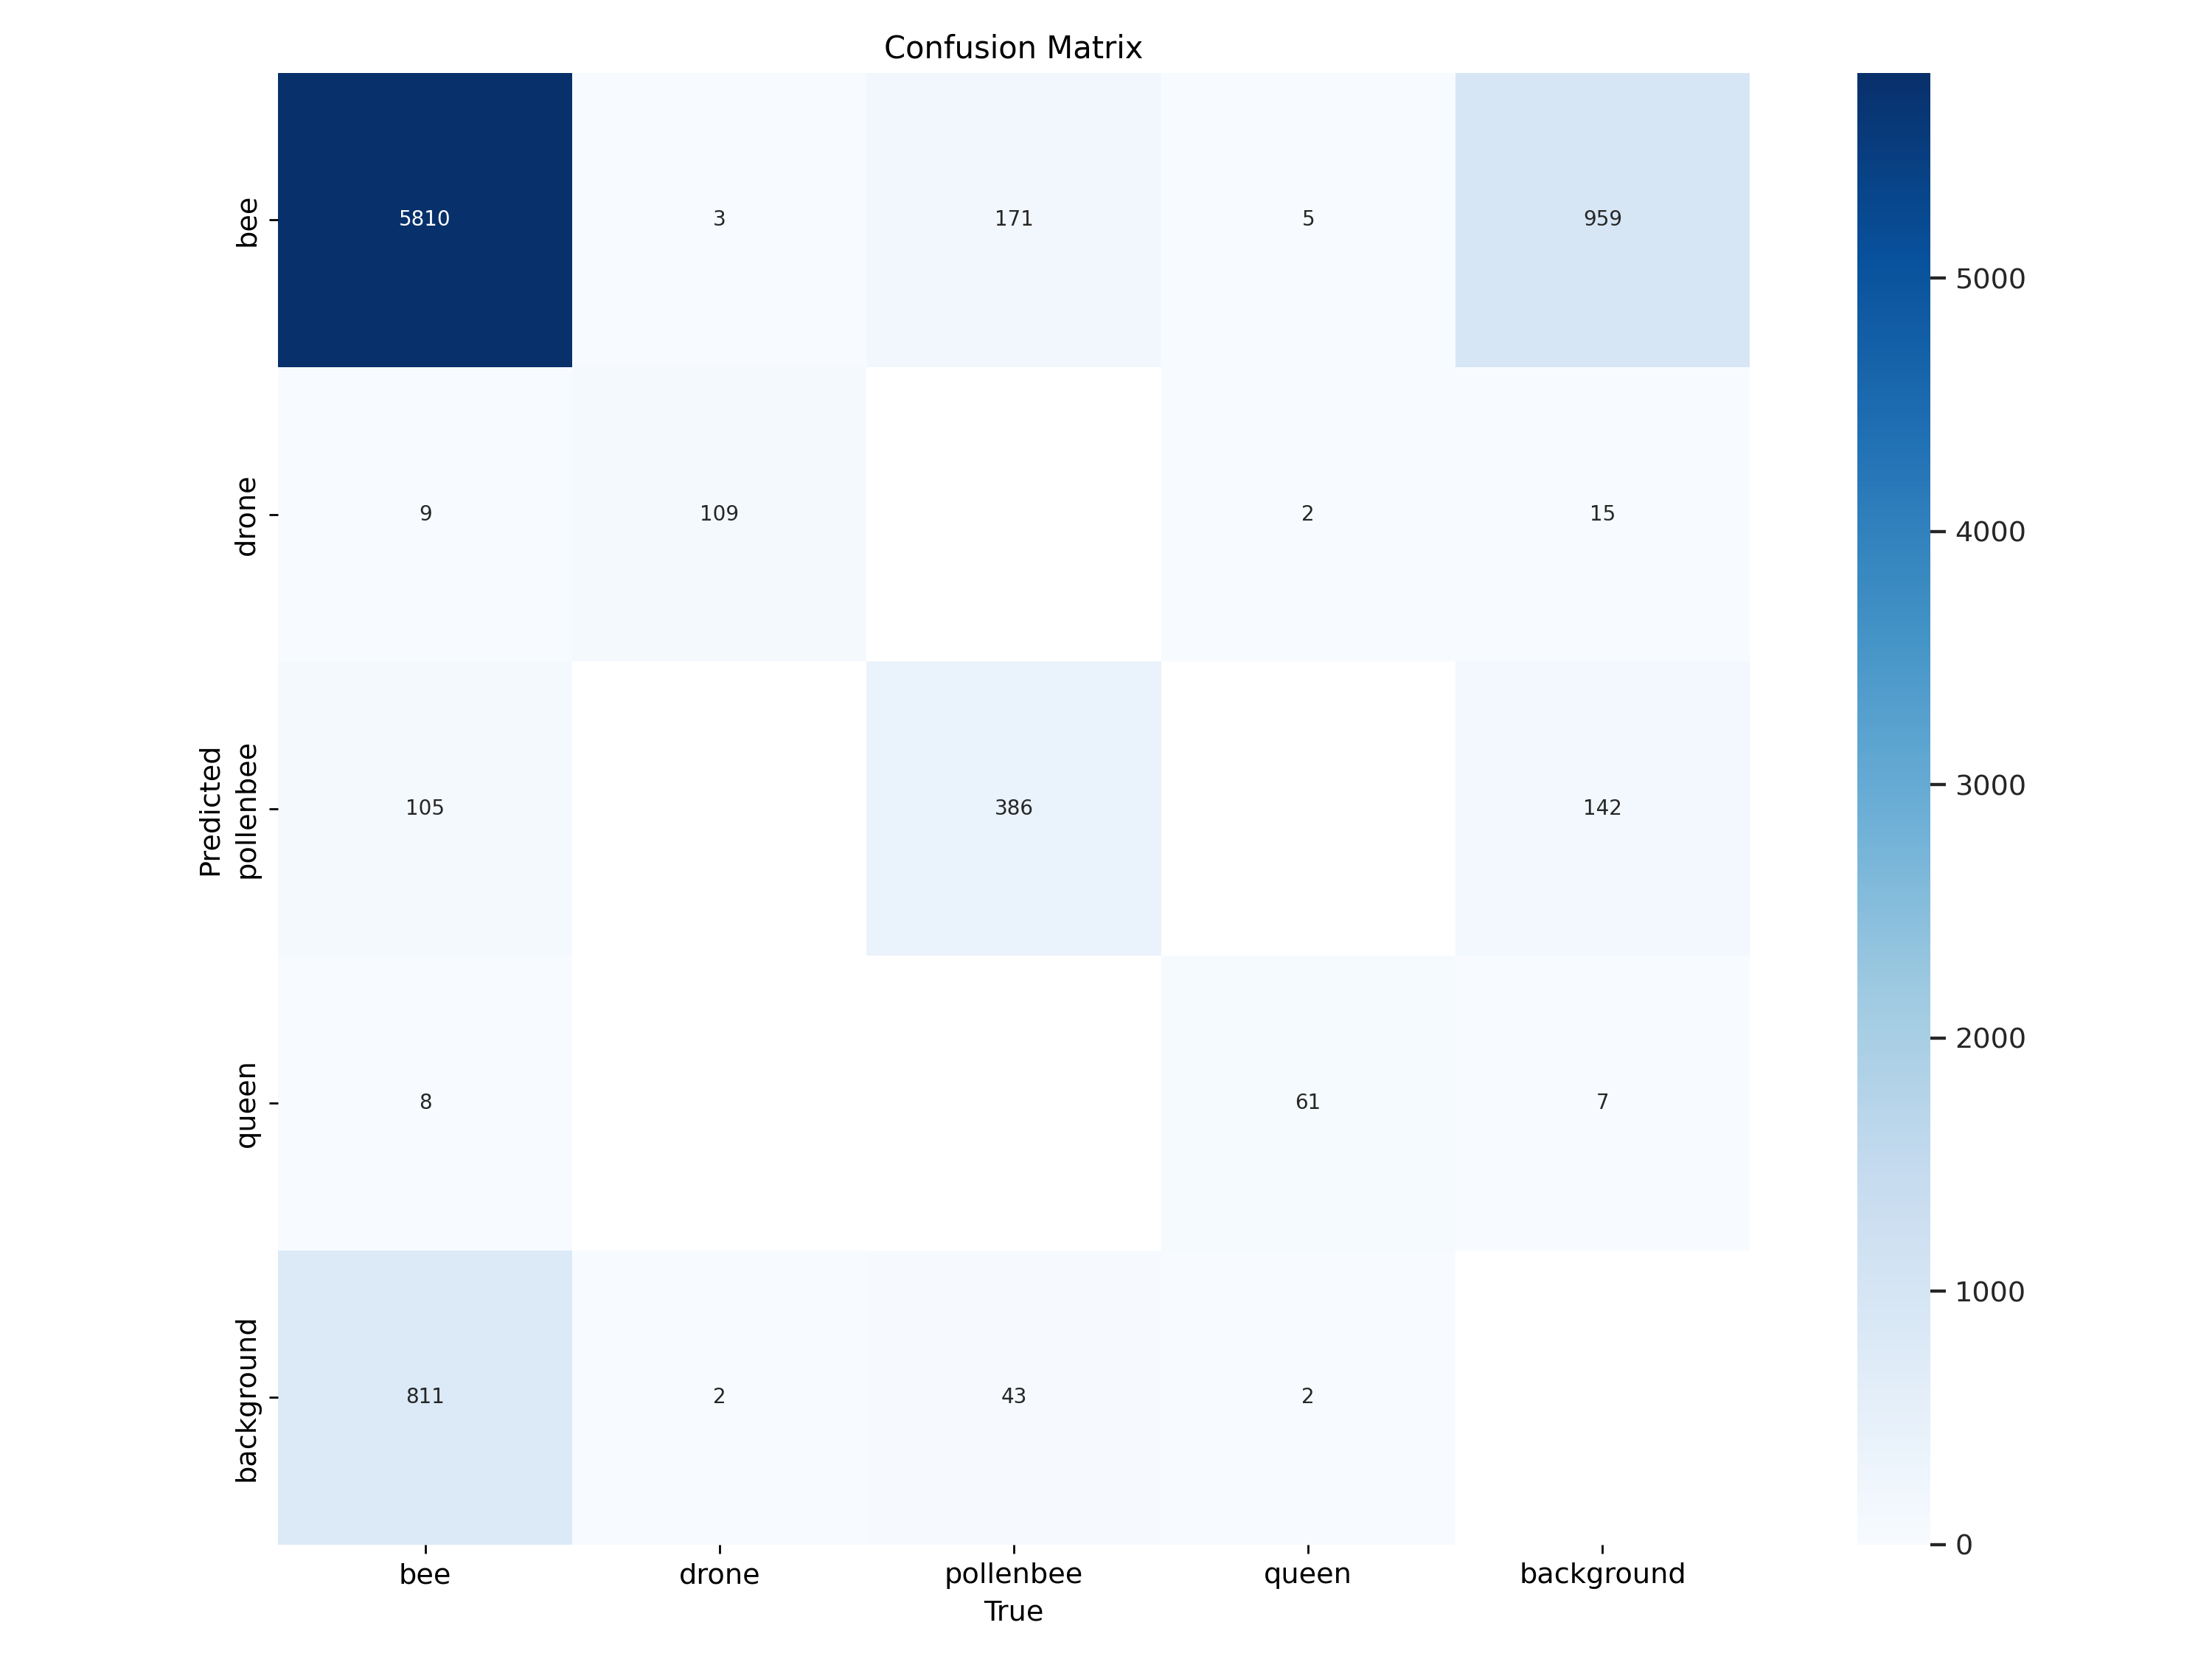

In [ ]:
Image(filename=f'/content/drive/MyDrive/bee-detection-dataset/runs/detect/train/confusion_matrix.png')

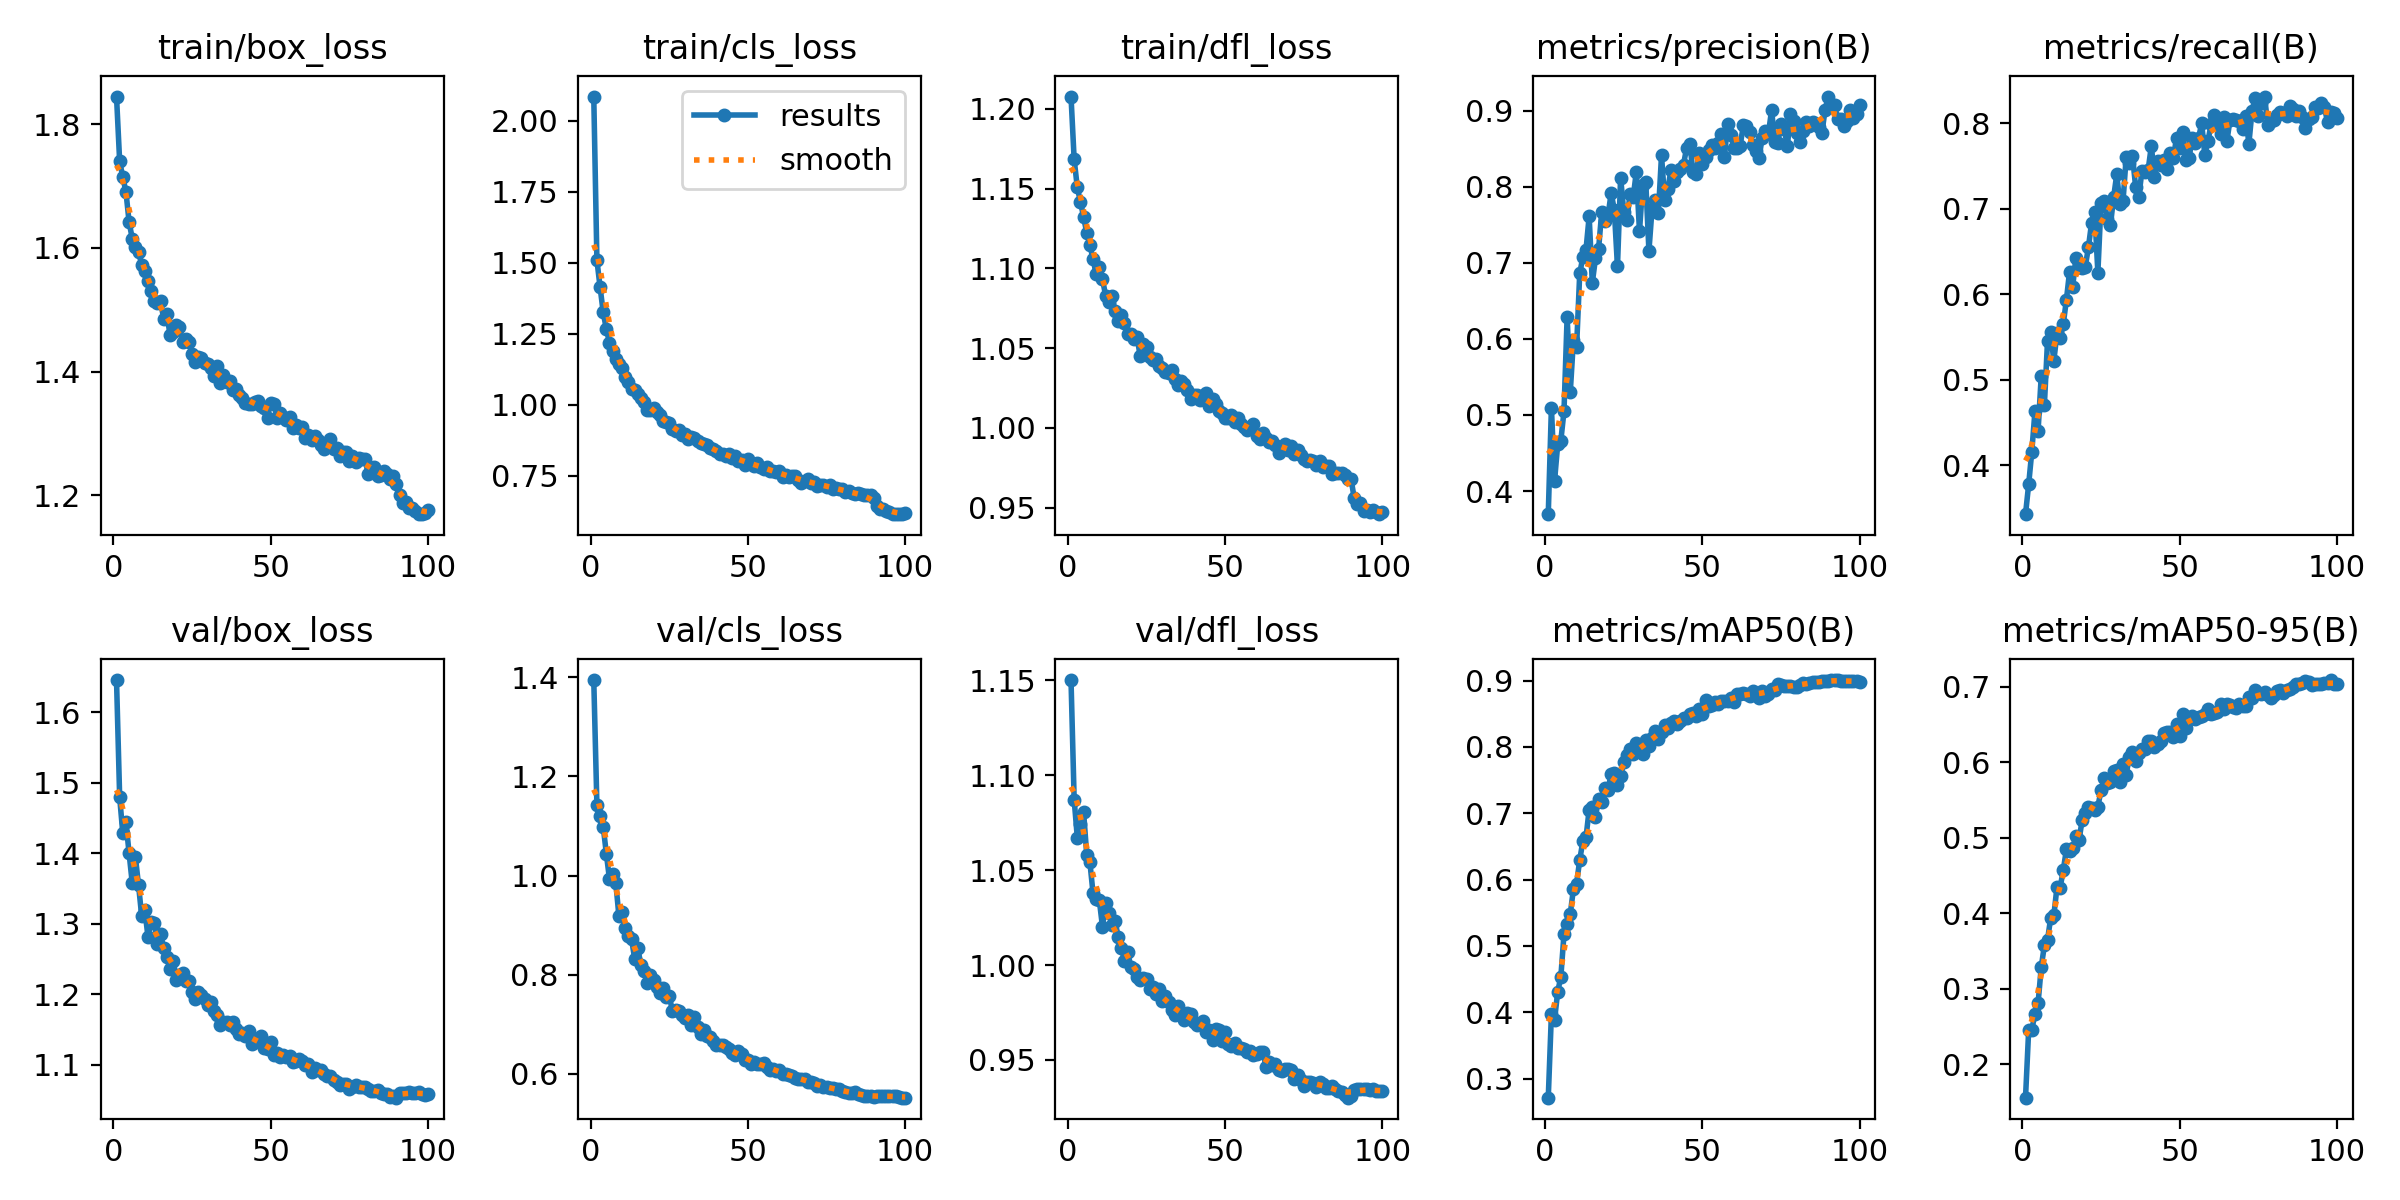

In [ ]:
Image(filename=f'/content/drive/MyDrive/bee-detection-dataset/runs/detect/train/results.png')

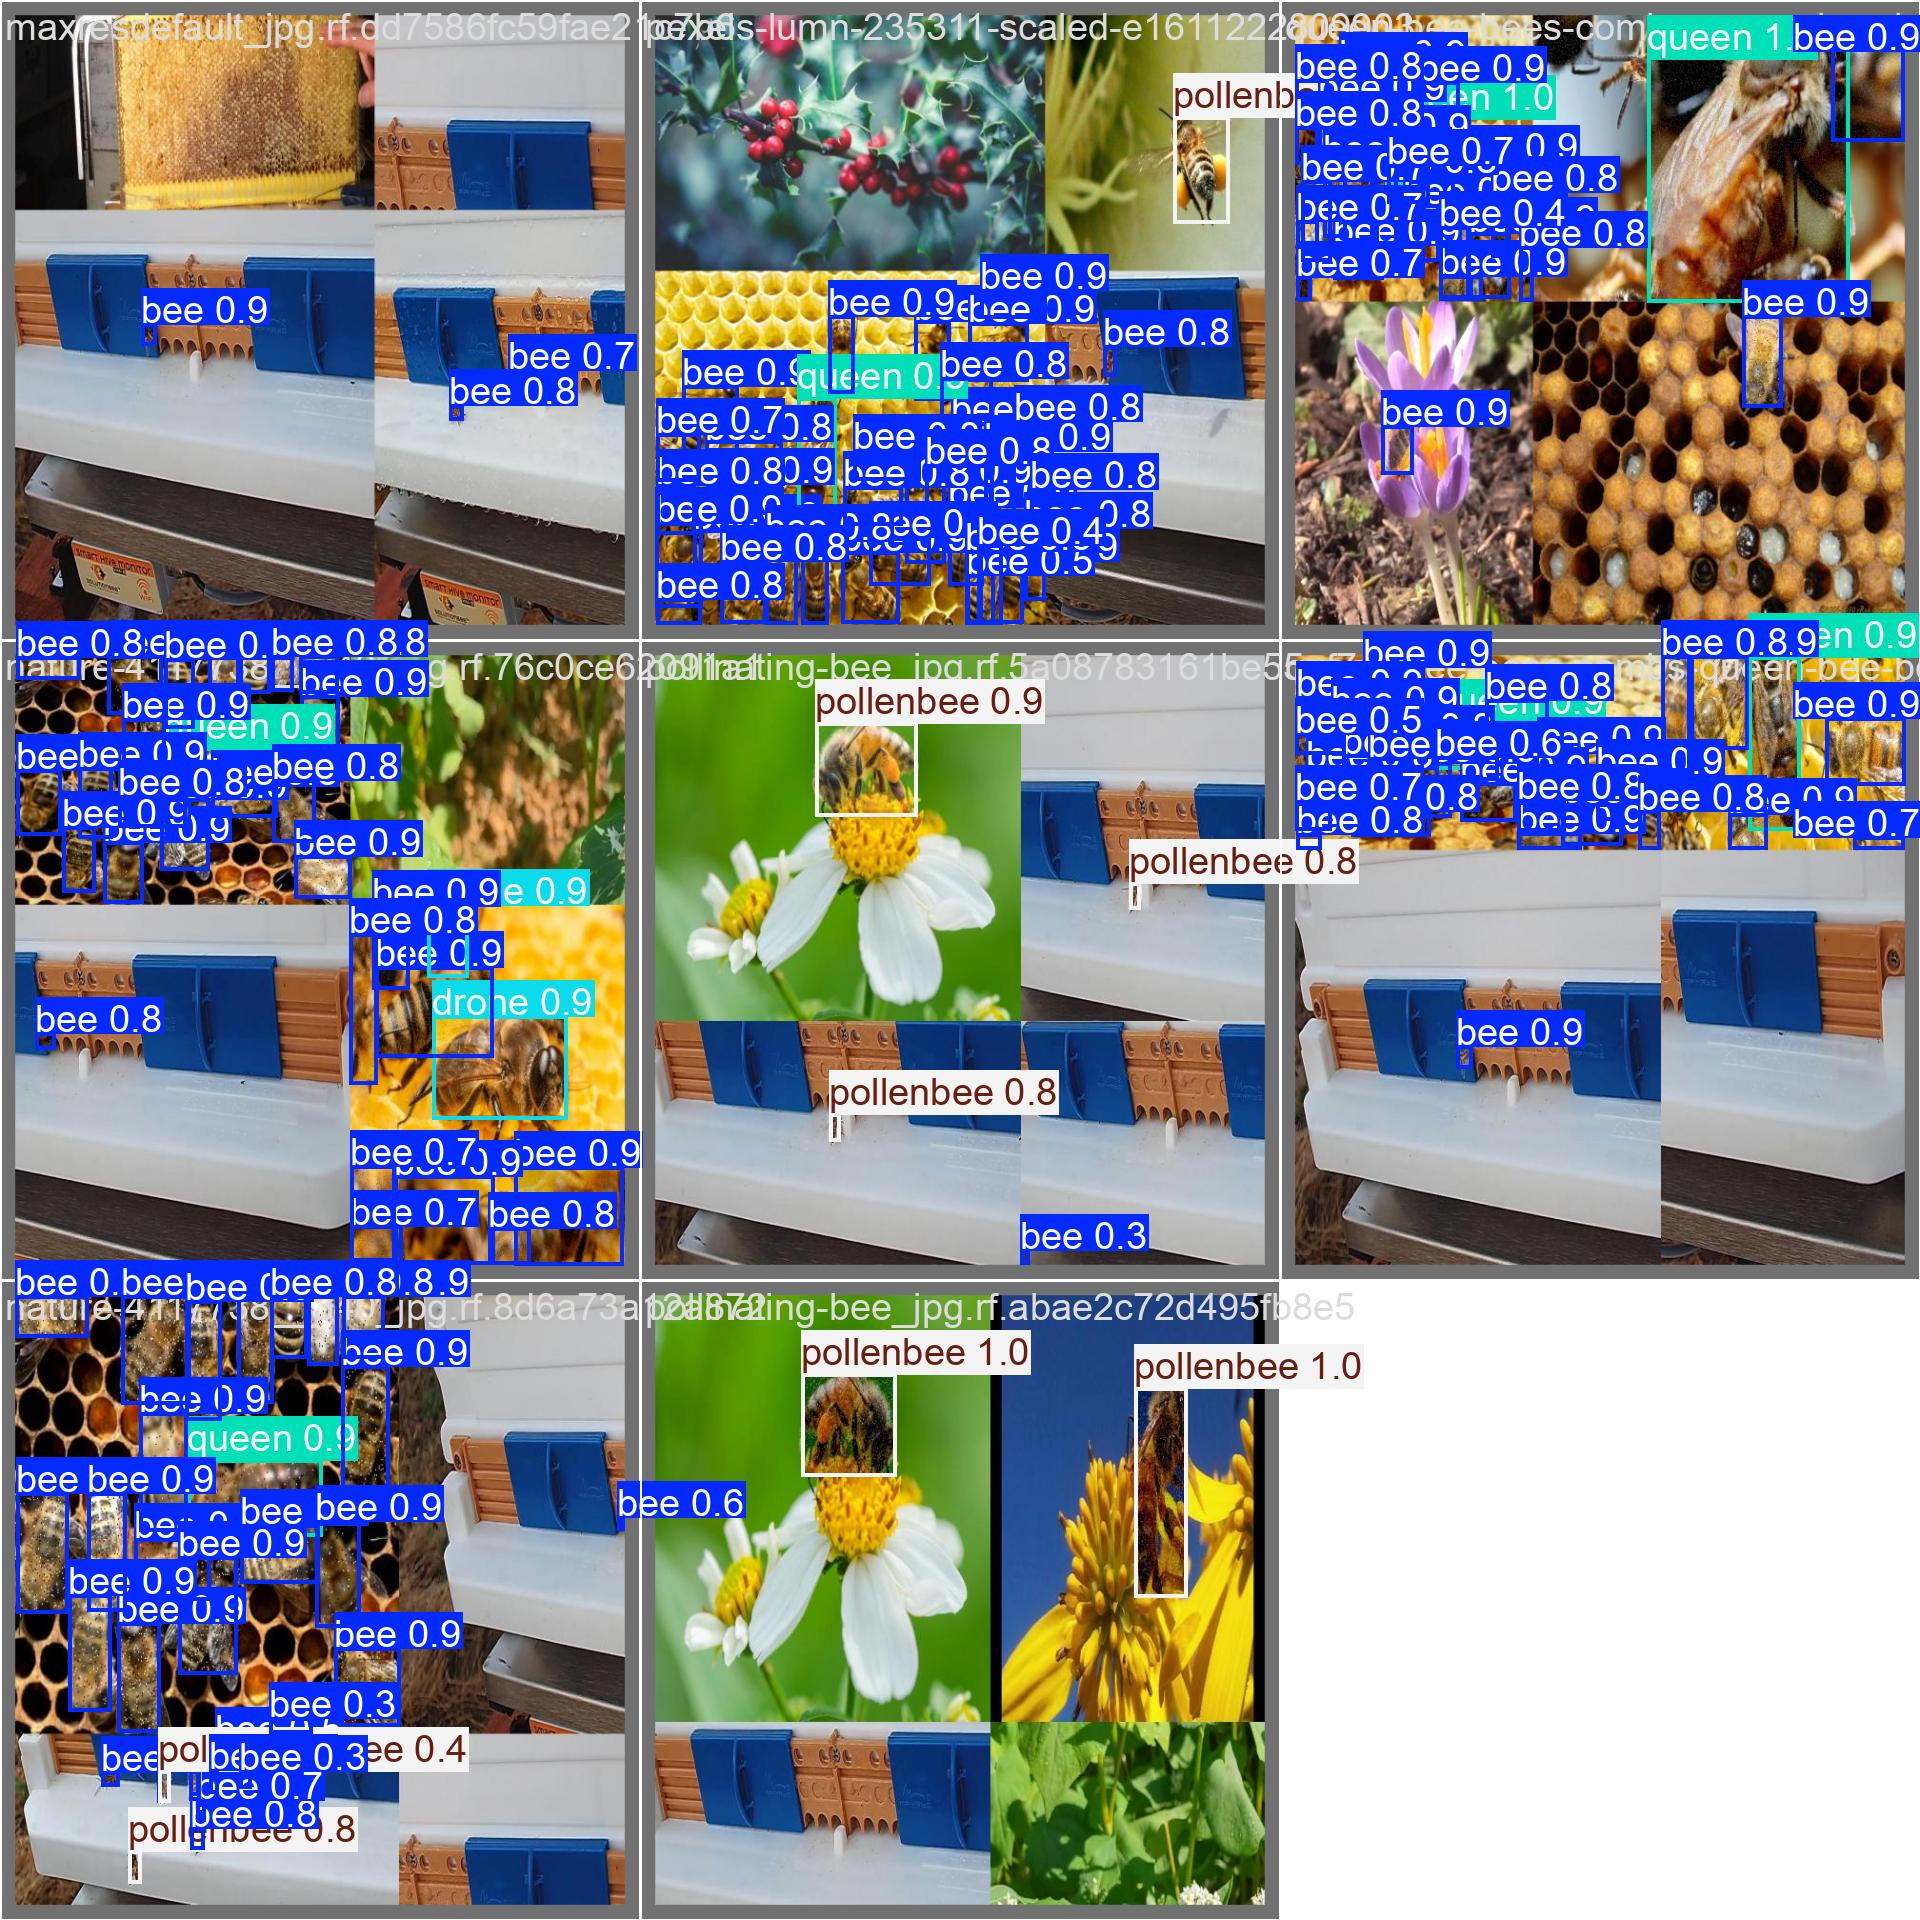

In [ ]:
Image(filename=f'/content/drive/MyDrive/bee-detection-dataset/runs/detect/train/val_batch0_pred.jpg', width=600)

### Validate the model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model=/content/drive/MyDrive/bee-detection-dataset/runs/detect/train/weights/best.pt data=/content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/data.yaml

/content/drive/MyDrive/bee-detection-dataset
Ultralytics 8.3.113 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv9t summary (fused): 197 layers, 1,971,564 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 47.2±8.8 MB/s, size: 56.1 KB)
val: Scanning /content/drive/MyDrive/bee-detection-dataset/datasets/Bee-Detection-1/valid/labels.cache... 530 images, 11 backgrounds, 0 corrupt: 100% 530/530 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 34/34 [00:06<00:00,  5.51it/s]
                   all        530       7527      0.891      0.814      0.899      0.708
                   bee        481       6743      0.932      0.786      0.901      0.594
                 drone         60        114      0.909      0.964      0.971      0.832
             pollenbee        285        600      0.834      0.633      0.791       0.58
                 queen         67      

### Deploying the Custom Model on YOLOvX App for Real-time Inference
Once you are satisfied with the model performance you can now simply download the model from Output directory and upload it to the YOLOvX App. Now simply RUN

### Now we can go back to:
https://community.yolovx.com/t/experiment-6-bee-detection-on-yolovx-app/67